# Banking Customer Analytics and Deposit Predictions Using Machine Learning

## 1. Project Introduction

### Project Overview
The Banking Customer Analytics Project aims to analyze customer demographic and financial data to uncover meaningful business insights that support data-driven decision-making. By exploring customer profiles, banking behavior, deposits, loans, and other financial indicators, this project helps identify valuable customer segments, understand financial trends, and improve overall business performance.

The analysis is performed using Python and its data analysis libraries, following a structured Exploratory Data Analysis (EDA).

### Business Problem
The bank wants to understand customer demographics, financial behavior, and product usage to support data-driven decision making. This project analyzes customer deposits, loans, income, savings, and risk profiles to identify valuable customer segments, improve customer retention, optimize banking services, and support strategic business decisions.

### Dataset Summary:
- Number of Records: 3,000
- Number of Features: 25
- Dataset Type: Structured (CSV)
- Granularity: Each row represents one unique customer.

## 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Load Dataset
- Read CSV
- Display First Few Rows

In [2]:
# Load the banking dataset into a DataFrame
df = pd.read_csv(r"D:\Banking-Analytics-Project\data\Banking.csv")

## 4. Inspect Dataset

In [3]:
df.head()

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [4]:
df.shape

(3000, 25)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client ID                 3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loa

In [6]:
df.columns

Index(['Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId'],
      dtype='object')

In [7]:
df.dtypes

Client ID                    object
Name                         object
Age                           int64
Location ID                   int64
Joined Bank                  object
Banking Contact              object
Nationality                  object
Occupation                   object
Fee Structure                object
Loyalty Classification       object
Estimated Income            float64
Superannuation Savings      float64
Amount of Credit Cards        int64
Credit Card Balance         float64
Bank Loans                  float64
Bank Deposits               float64
Checking Accounts           float64
Saving Accounts             float64
Foreign Currency Account    float64
Business Lending            float64
Properties Owned              int64
Risk Weighting                int64
BRId                          int64
GenderId                      int64
IAId                          int64
dtype: object

In [8]:
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


## 5. Data Cleaning
Perform all necessary preprocessing.

Include:
- Handle Missing Values
- Remove Duplicates
- Correct Data Types
- Convert Date Columns

### Handling Missing Values

In [9]:
df.isnull().sum()

Client ID                   0
Name                        0
Age                         0
Location ID                 0
Joined Bank                 0
Banking Contact             0
Nationality                 0
Occupation                  0
Fee Structure               0
Loyalty Classification      0
Estimated Income            0
Superannuation Savings      0
Amount of Credit Cards      0
Credit Card Balance         0
Bank Loans                  0
Bank Deposits               0
Checking Accounts           0
Saving Accounts             0
Foreign Currency Account    0
Business Lending            0
Properties Owned            0
Risk Weighting              0
BRId                        0
GenderId                    0
IAId                        0
dtype: int64

In [10]:
df.isnull().sum().sum()

np.int64(0)

### Handling Duplicate Values

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Client ID"].duplicated().sum()

np.int64(60)

In [13]:
df["Client ID"].value_counts()

Client ID
IND48103    3
IND66163    2
IND35051    2
IND52909    2
IND45303    2
           ..
IND78463    1
IND90097    1
IND91317    1
IND61281    1
IND40216    1
Name: count, Length: 2940, dtype: int64

In [14]:
df[df["Client ID"].duplicated(keep=False)].sort_values("Client ID")

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
1545,IND15088,Margaret Coleman,42,8628,25-12-2010,Keith Griffin,American,Systems Administrator III,Mid,Silver,...,1822218.15,1111108.63,192592.16,38869.65,2515317.76,3,3,3,2,16
740,IND15088,Betty Davis,56,12337,14-03-2013,Jesse Evans,European,Marketing Manager,Mid,Silver,...,515252.11,197330.60,182421.17,29202.53,460614.28,1,1,3,1,8
378,IND15955,Susan Dunn,20,2035,08-12-2011,Jason Duncan,Asian,Programmer Analyst IV,Mid,Jade,...,1065362.14,532681.07,288300.04,23692.05,1671865.90,2,4,3,2,5
1081,IND15955,Victor Williams,21,26992,29-05-2015,Mark Montgomery,African,Research Assistant IV,High,Jade,...,280450.11,146541.50,55180.45,1292.64,792193.58,1,1,1,2,9
995,IND17019,Keith Fuller,70,14000,25-10-2014,Jesse Evans,European,Registered Nurse,High,Silver,...,2168373.56,827623.49,438640.45,36083.69,2552969.13,3,5,3,1,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,IND94062,Kathryn Graham,76,29597,26-12-2014,Roger Alexander,American,Paralegal,High,Jade,...,336743.01,270342.98,244731.54,9086.27,587666.47,2,1,3,1,3
2901,IND96193,Adam Murphy,54,21076,28-07-2009,Samuel Fowler,European,Programmer IV,Mid,Silver,...,1498393.77,926487.75,265135.63,6216.63,1601429.81,0,2,1,1,12
2013,IND96193,Lori Hawkins,44,34985,29-08-2009,Joshua Little,American,Account Representative II,High,Gold,...,231512.59,260911.01,130014.53,9377.33,154414.81,2,1,3,1,8
1738,IND97314,John Davis,80,38563,09-01-2020,Paul Holmes,American,Senior Financial Analyst,High,Jade,...,670727.85,284949.74,188724.40,10233.14,1324654.98,2,1,2,2,5


### Data Type Conversion

In [15]:
df["Joined Bank"] = pd.to_datetime(df["Joined Bank"], format = "%d-%m-%Y")

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Client ID                 3000 non-null   object        
 1   Name                      3000 non-null   object        
 2   Age                       3000 non-null   int64         
 3   Location ID               3000 non-null   int64         
 4   Joined Bank               3000 non-null   datetime64[ns]
 5   Banking Contact           3000 non-null   object        
 6   Nationality               3000 non-null   object        
 7   Occupation                3000 non-null   object        
 8   Fee Structure             3000 non-null   object        
 9   Loyalty Classification    3000 non-null   object        
 10  Estimated Income          3000 non-null   float64       
 11  Superannuation Savings    3000 non-null   float64       
 12  Amount of Credit Car

### Explore Categorical and Numerical Data

In [17]:
# Display all numerical columns in dataset

num_cols = df.select_dtypes(include = ["int","float"]).columns
num_cols

Index(['Age', 'Location ID', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId'],
      dtype='object')

In [18]:
# Display all String columns in dataset

obj_cols = df.select_dtypes(include = ["object"]).columns
obj_cols

Index(['Client ID', 'Name', 'Banking Contact', 'Nationality', 'Occupation',
       'Fee Structure', 'Loyalty Classification'],
      dtype='object')

In [19]:
# Lenght of columns

print("Number of numerical columns: ",len(num_cols))
print("Number of text columns: ",len(obj_cols))

Number of numerical columns:  17
Number of text columns:  7


In [20]:
# Display unique values in the Gender column

df["GenderId"].unique()

array([1, 2])

In [21]:
# Count the number of customers by gender

df["GenderId"].value_counts().sort_index()

GenderId
1    1488
2    1512
Name: count, dtype: int64

## 6. EDA

## A. Customer Profile Analysis
Understand Customer Base

### 1. Customer Distribution by Gender

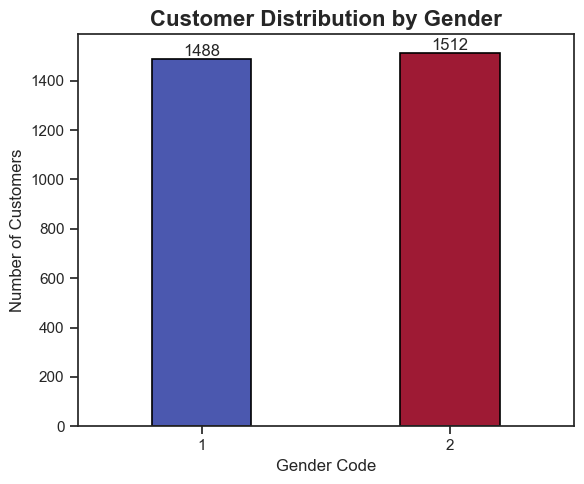

In [22]:
#Countplot

sns.set_theme(style = "ticks")
plt.figure(figsize=(6,5))
a = sns.countplot(
    data = df,  
    x = 'GenderId',  
    hue = 'GenderId', 
    palette = 'coolwarm', 
    width = 0.4,  
    edgecolor = 'black',  
    linewidth = 1.2, 
    legend = False
)
for container in a.containers:
    a.bar_label(container)

plt.title("Customer Distribution by Gender", fontsize =16, fontweight = 'bold')
plt.xlabel("Gender Code", fontsize = 12)
plt.ylabel("Number of Customers", fontsize = 12)
plt.tight_layout()
plt.show()

### Business Observation

- Gender Code 1 has 1,512 customers.
- Gender Code 2 has 1,488 customers.
- The customer base is almost evenly distributed between the two gender categories.
- No significant imbalance is observed, indicating equal representation.

### 2. Customer Age Distribution

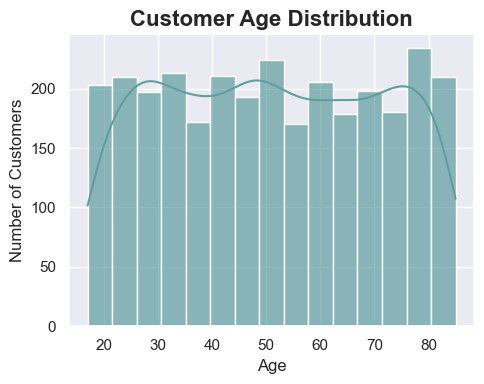

In [23]:
# Histogram using KDE

sns.set_theme(style = "darkgrid")
plt.figure(figsize=(5,4))
a = sns.histplot(data=df, x="Age", bins=15, kde=True, color="cadetblue", edgecolor="white", alpha=0.7)

plt.title("Customer Age Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Age", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.tight_layout()
plt.show()

### 3. Nationality Distribution

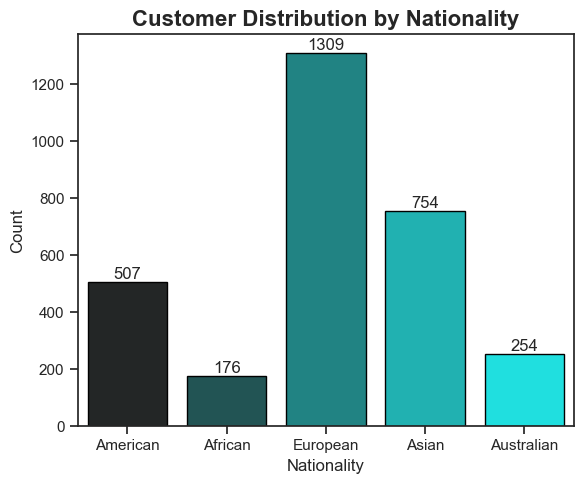

In [24]:
# Countplot

sns.set_theme(style="ticks")
plt.figure(figsize=(6,5))
a = sns.countplot(
    data=df,
    x="Nationality",
    hue="Nationality",
    edgecolor="black",
    palette='dark:cyan'
)
for container in a.containers:
    a.bar_label(container)

plt.title("Customer Distribution by Nationality", fontsize=16, fontweight="bold")
plt.xlabel("Nationality",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.tight_layout()
plt.show()

### 4. Top 10 Occupations by Number of Customers

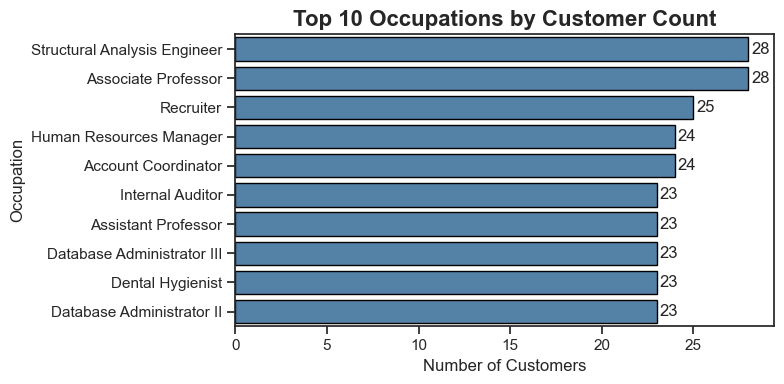

In [25]:
# Barplot

top10_occupation = df["Occupation"].value_counts().head(10)
sns.set_theme(style="ticks")
plt.figure(figsize=(8,4))
a = sns.barplot(x=top10_occupation.values, 
                y=top10_occupation.index, 
                edgecolor="black", 
                color = "steelblue",
                legend=False
)
for container in a.containers:
    a.bar_label(container, padding=2)

plt.title("Top 10 Occupations by Customer Count", fontsize=16, fontweight="bold")
plt.xlabel("Number of Customers",fontsize=12)
plt.ylabel("Occupation",fontsize=12)
plt.tight_layout()
plt.show()

### 5. Loyalty Classification Distribution

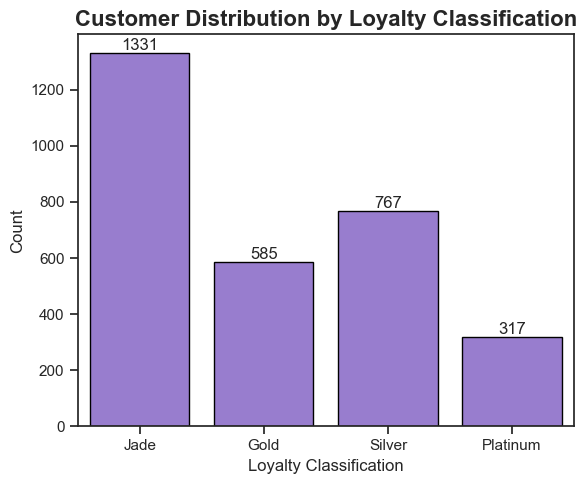

In [26]:
#Countplot

sns.set_theme(style="ticks")
plt.figure(figsize=(6,5))
a = sns.countplot(data=df, x="Loyalty Classification", color="mediumpurple", edgecolor="black", )

for container in a.containers:
    a.bar_label(container)
plt.title("Customer Distribution by Loyalty Classification", fontsize=16, fontweight="bold")
plt.xlabel("Loyalty Classification", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

### 6. Distribution of Customer Fee Structure

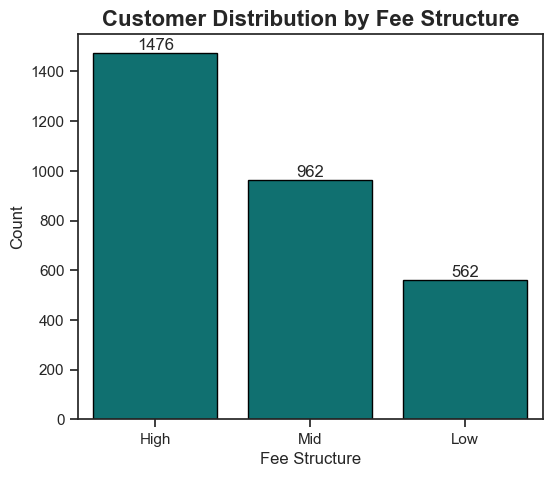

In [27]:
# CountPlot

sns.set_theme(style="ticks")
plt.figure(figsize=(6,5))
a = sns.countplot(data=df, x="Fee Structure", color="teal", edgecolor="black")

for container in a.containers:
    a.bar_label(container)
plt.title("Customer Distribution by Fee Structure", fontsize=16, fontweight="bold")
plt.xlabel("Fee Structure",fontsize=12)
plt.ylabel("Count",fontsize=12)

plt.show()

## B. Financial Analysis
Understand Customer Financial Behavior

### 1. Distribution of Customer Bank Deposits

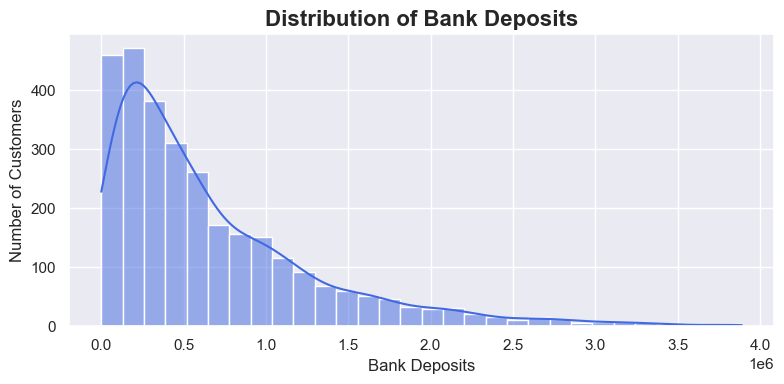

In [28]:
# Histrogram

sns.set_theme(style="darkgrid")
plt.figure(figsize=(8,4))
sns.histplot(data=df, x="Bank Deposits", bins=30, kde=True, color="royalblue", edgecolor="white")

plt.title("Distribution of Bank Deposits", fontsize=16, fontweight="bold")
plt.xlabel("Bank Deposits", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.tight_layout()
plt.show()

### 2. Top 10 Occupations by Total Bank Deposits

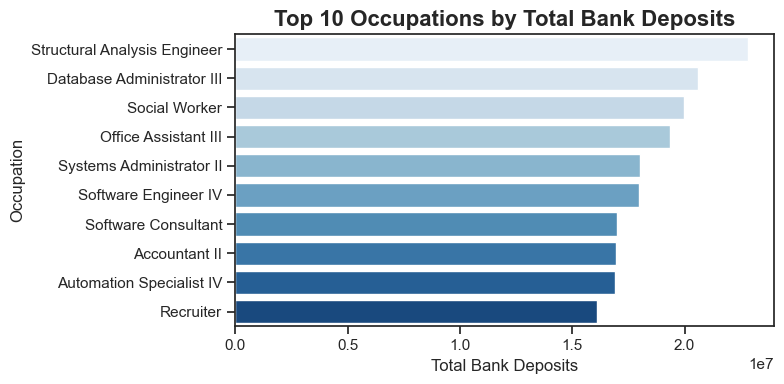

In [29]:
# Barplot

top10_deposits = (df.groupby("Occupation")["Bank Deposits"].sum().sort_values(ascending=False).head(10).reset_index())
sns.set_theme(style="ticks")
plt.figure(figsize=(8,4))
a = sns.barplot(data=top10_deposits, x="Bank Deposits", y="Occupation", hue="Occupation", palette="Blues",legend=False)
    
plt.title("Top 10 Occupations by Total Bank Deposits", fontsize=16, fontweight="bold")
plt.xlabel("Total Bank Deposits",  fontsize=12)
plt.ylabel("Occupation",  fontsize=12)
plt.tight_layout()
plt.show()

### 3. Estimated Income Distribution

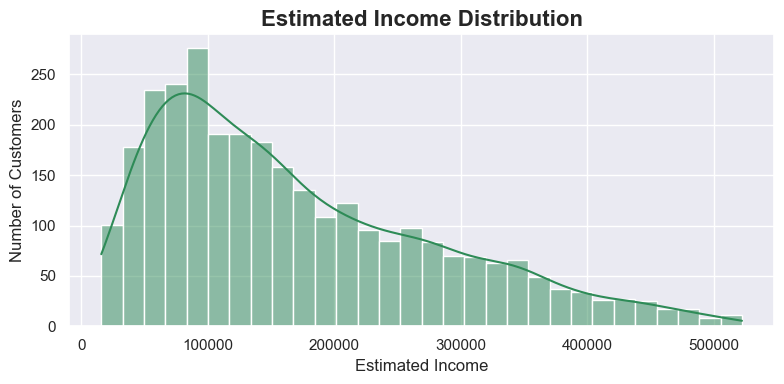

In [30]:
# Histogram
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8,4))
sns.histplot(data=df, x="Estimated Income", bins=30, kde=True, color="seagreen", edgecolor="white")

plt.title("Estimated Income Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Estimated Income", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.tight_layout()
plt.show()

### 4. Distribution of Customer Loan Amounts

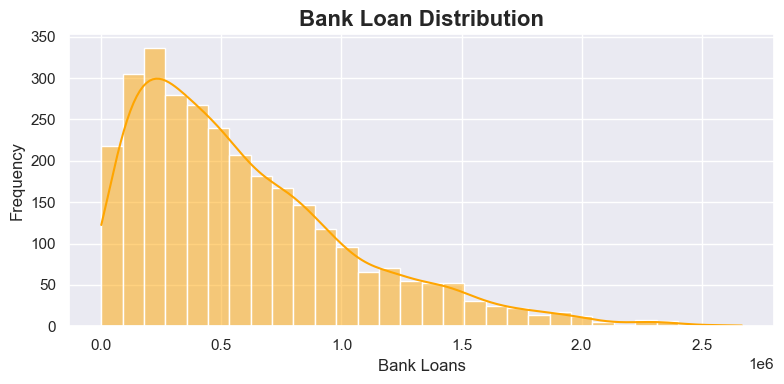

In [31]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8,4))
sns.histplot(
    data=df,
    x="Bank Loans",
    bins=30,
    kde=True,
    color="orange"
)
plt.title("Bank Loan Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Bank Loans",fontsize=12)
plt.ylabel("Frequency",fontsize=12)
plt.tight_layout()
plt.show()

### 5. Top 10 Occupations by Total Bank Loans

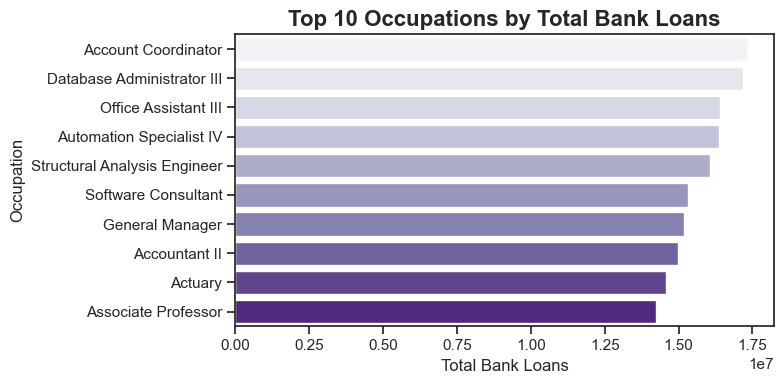

In [32]:
# Barplot

top10_deposits = (df.groupby("Occupation")["Bank Loans"].sum().sort_values(ascending=False).head(10).reset_index())
sns.set_theme(style="ticks")
plt.figure(figsize=(8,4))
a = sns.barplot(data=top10_deposits, x="Bank Loans", y="Occupation", hue="Occupation", palette="Purples",legend=False)
    
plt.title("Top 10 Occupations by Total Bank Loans", fontsize=16, fontweight="bold")
plt.xlabel("Total Bank Loans",  fontsize=12)
plt.ylabel("Occupation",  fontsize=12)
plt.tight_layout()
plt.show()

### 6. Distribution of Customer Savings Balance

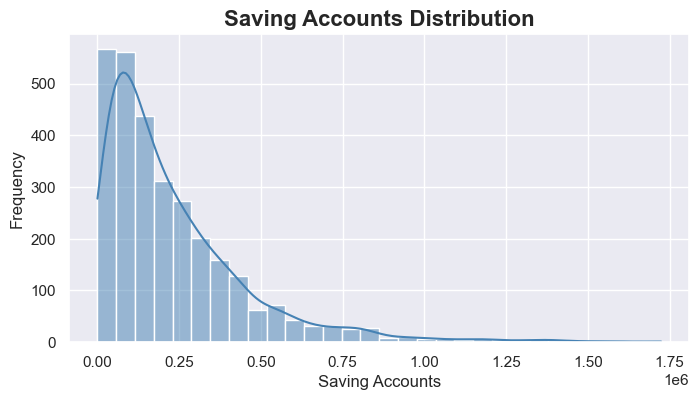

In [33]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8,4))
sns.histplot(
    data=df,
    x="Saving Accounts",
    bins=30,
    kde=True,
    color="steelblue"
)
plt.title("Saving Accounts Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Saving Accounts", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

### 7. Risk Weighting Distribution

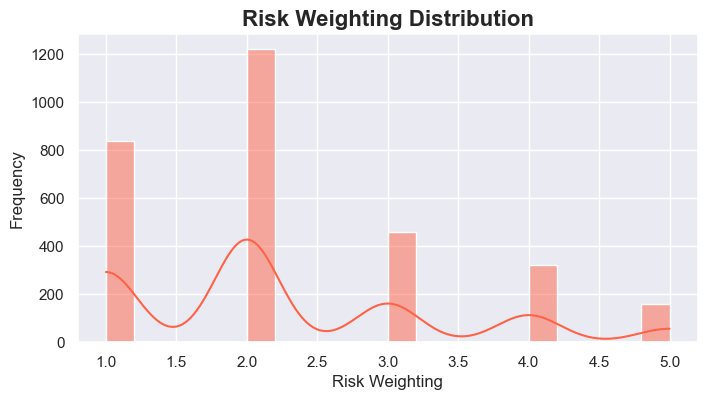

In [34]:
# Histogram 

sns.set_theme(style="darkgrid")
plt.figure(figsize=(8,4))
sns.histplot(
    data=df,
    x="Risk Weighting",
    bins=20,
    kde=True,
    color="tomato",
    edgecolor="white"
)
plt.title("Risk Weighting Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Risk Weighting",fontsize=12)
plt.ylabel("Frequency",fontsize=12)
plt.show()

## C. Relationship Analysis
Identify Realtionships Between Varibles

### 1. Relationship Between Estimated Income and Bank Deposits

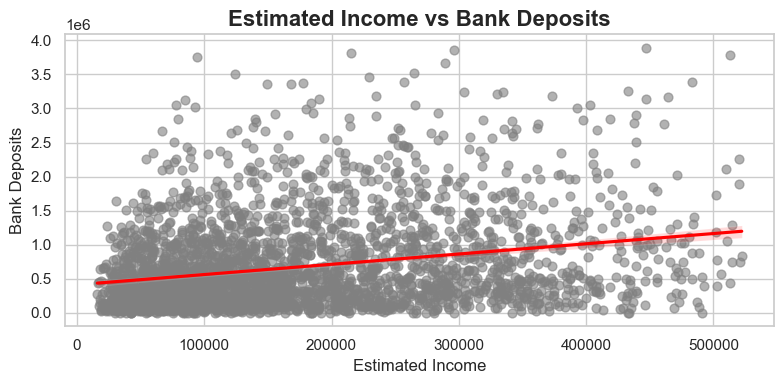

In [35]:
# Scatter plot with the regression line

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,4))
sns.regplot(
    data=df, 
    x="Estimated Income", 
    y="Bank Deposits", 
    color = 'grey', 
    scatter_kws={"alpha": 0.6, "s": 40}, 
    line_kws={"color": "red"}
)
plt.title("Estimated Income vs Bank Deposits", fontsize=16, fontweight="bold")
plt.xlabel("Estimated Income", fontsize=12)
plt.ylabel("Bank Deposits", fontsize=12)
plt.tight_layout()
plt.show()

## D. Correlation Analysis
Use a correlation heatmap.

### 1. Correlation Between Banking Variables

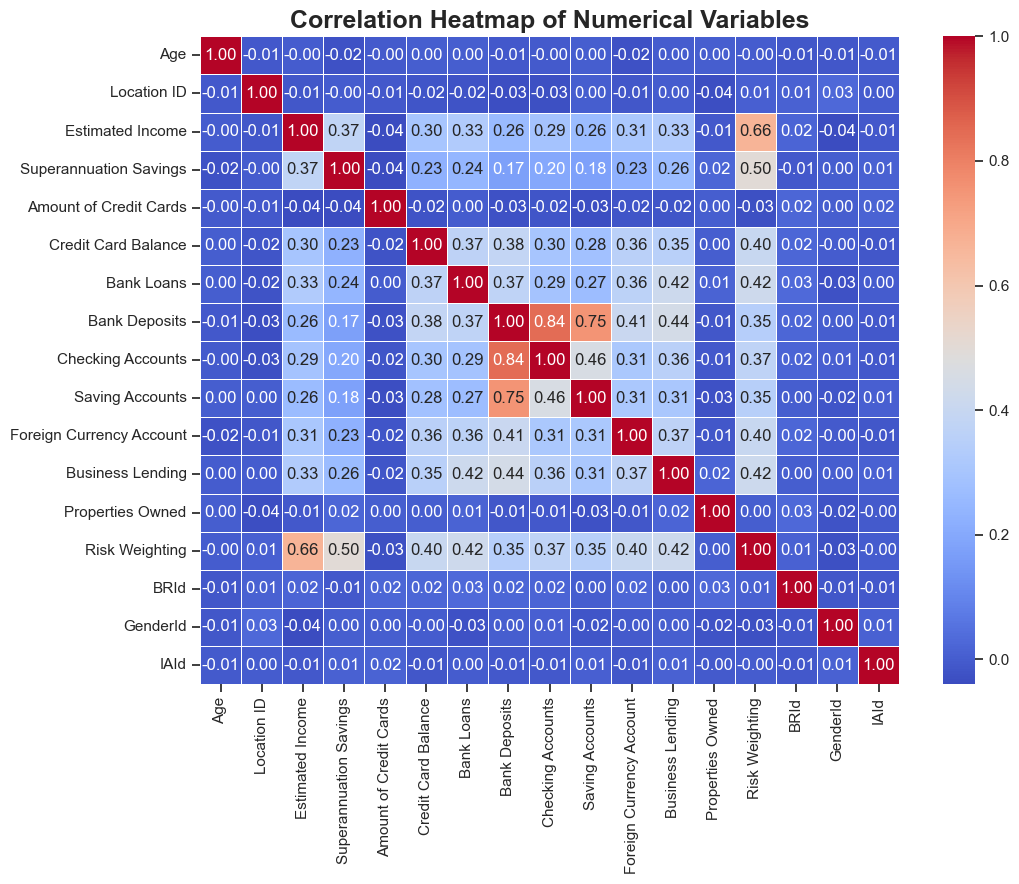

In [36]:
# Correlation Heatmap

sns.set_theme(style="ticks")
plt.figure(figsize = (11,9))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm', fmt=".2f", linewidth=0.5)

plt.title("Correlation Heatmap of Numerical Variables",fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Machine Learning

### Step 1: Import Required ML Libraries

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import(mean_absolute_error, mean_squared_error, r2_score)

### Step 2: Select Features (X) and Target (y)

In [38]:
X = df.drop(columns=["Client ID", "Bank Deposits"])
y = df["Bank Deposits"]

### Step 3: Check Features

In [39]:
print("Features Shape", X.shape)
print("Target Shape", y.shape)
X.head()

Features Shape (3000, 23)
Target Shape (3000,)


,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,Estimated Income,...,Bank Loans,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,Raymond Mills,24,34324,2019-05-06,Anthony Torres,American,Safety Technician IV,High,Jade,75384.77,...,776242.92,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,Julia Spencer,23,42205,2001-12-10,Jonathan Hawkins,African,Software Consultant,High,Jade,289834.31,...,1270615.43,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,Stephen Murray,27,7314,2010-01-25,Anthony Berry,European,Help Desk Operator,High,Gold,169935.23,...,1052715.84,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,Virginia Garza,40,34594,2019-03-28,Steve Diaz,American,Geologist II,Mid,Silver,356808.11,...,121195.06,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,Melissa Sanders,46,41269,2012-07-20,Shawn Long,American,Assistant Professor,Mid,Platinum,130711.68,...,1048301.95,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


### Step 4. Encode Categorical Variable

In [40]:
LE = LabelEncoder()
obj_cols = X.select_dtypes(include=["object"]).columns
for col in obj_cols:
    X[col]=LE.fit_transform(X[col])
X.head()

,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,Estimated Income,...,Bank Loans,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,2289,24,34324,2019-05-06,3,1,144,0,1,75384.77,...,776242.92,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,1579,23,42205,2001-12-10,25,0,154,0,1,289834.31,...,1270615.43,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,2646,27,7314,2010-01-25,1,4,87,0,0,169935.23,...,1052715.84,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,2833,40,34594,2019-03-28,45,1,79,2,3,356808.11,...,121195.06,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,2012,46,41269,2012-07-20,42,1,24,2,2,130711.68,...,1048301.95,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


### Step 5: Verify Data Types

In [41]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Name                      3000 non-null   int64         
 1   Age                       3000 non-null   int64         
 2   Location ID               3000 non-null   int64         
 3   Joined Bank               3000 non-null   datetime64[ns]
 4   Banking Contact           3000 non-null   int64         
 5   Nationality               3000 non-null   int64         
 6   Occupation                3000 non-null   int64         
 7   Fee Structure             3000 non-null   int64         
 8   Loyalty Classification    3000 non-null   int64         
 9   Estimated Income          3000 non-null   float64       
 10  Superannuation Savings    3000 non-null   float64       
 11  Amount of Credit Cards    3000 non-null   int64         
 12  Credit Card Balance 

In [42]:
# Remove datetime column
X = X.drop(columns=["Joined Bank"])

In [43]:
X.dtypes

Name                          int64
Age                           int64
Location ID                   int64
Banking Contact               int64
Nationality                   int64
Occupation                    int64
Fee Structure                 int64
Loyalty Classification        int64
Estimated Income            float64
Superannuation Savings      float64
Amount of Credit Cards        int64
Credit Card Balance         float64
Bank Loans                  float64
Checking Accounts           float64
Saving Accounts             float64
Foreign Currency Account    float64
Business Lending            float64
Properties Owned              int64
Risk Weighting                int64
BRId                          int64
GenderId                      int64
IAId                          int64
dtype: object

### Step 6: Split the Dataset

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state = 42)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (2400, 22)
Testing Data Shape: (600, 22)


## Linear Regression
Linear Regression is used as a baseline regression model to predict customer bank deposits. It estimates the relationship between the target variable and multiple independent features, providing a simple and interpretable benchmark for comparison with more advanced machine learning models.

### step 7: Train the Linear Regression Model

In [45]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


### STep 8: Make Predictions

In [46]:
# Predicting the Bank Deposits for the test data
y_pred = linear_model.predict(X_test)
print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[ 678545.77779801  913727.87942541  215253.0610122   630373.58490871
 1561427.75722966 1454280.93635609 1264469.81967036  224120.44720554
  856532.39791775  104946.29300968]


 ### Step 9: Evaluate the Model

In [65]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("-" * 35)
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

Linear Regression Performance
-----------------------------------
MAE  : 141245.14
MSE  : 37714968500.34
RMSE : 194203.42
R² Score : 0.9103


### Step 10: Actual vs Predicted Values

In [48]:
comparison = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred})
comparison.head(10)

,Actual,Predicted
0,550849.92,6.785458e+05
1,793170.72,9.137279e+05
2,286537.87,2.152531e+05
3,958605.57,6.303736e+05
4,1020870.62,1.561428e+06
5,1217834.19,1.454281e+06
6,1392924.89,1.264470e+06
7,303439.38,2.241204e+05
8,801883.53,8.565324e+05
9,146402.02,1.049463e+05


### Step 11: Visualize Actual vs Predicted (Linear Regression)

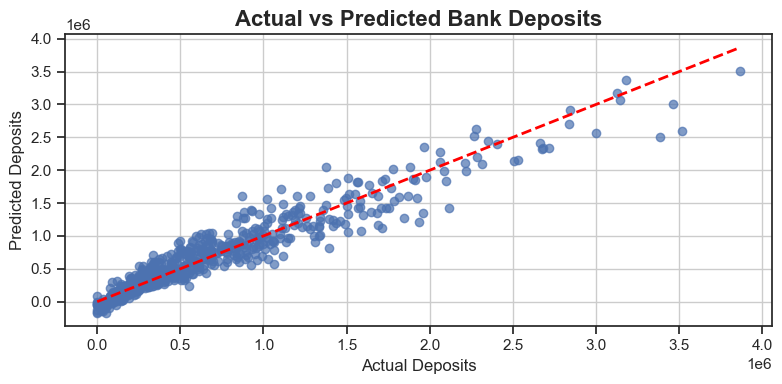

In [49]:
# Actual vs Predicted Scatter Plot

plt.figure(figsize=(8,4))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    linewidth=2
)
plt.title("Actual vs Predicted Bank Deposits", fontsize=16, fontweight="bold")
plt.xlabel("Actual Deposits",fontsize=12)
plt.ylabel("Predicted Deposits",fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

### Step 12: Residual Plot

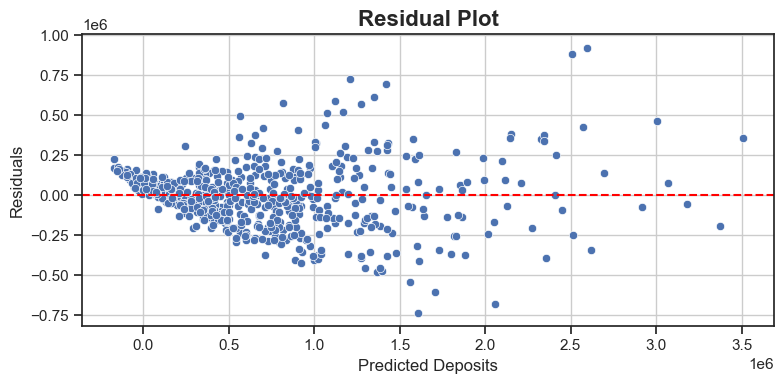

In [50]:
residuals = y_test - y_pred
plt.figure(figsize=(8,4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)
plt.title("Residual Plot", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Deposits",fontsize=12)
plt.ylabel("Residuals",fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

### Step 13: Distribution of Prediction Errors

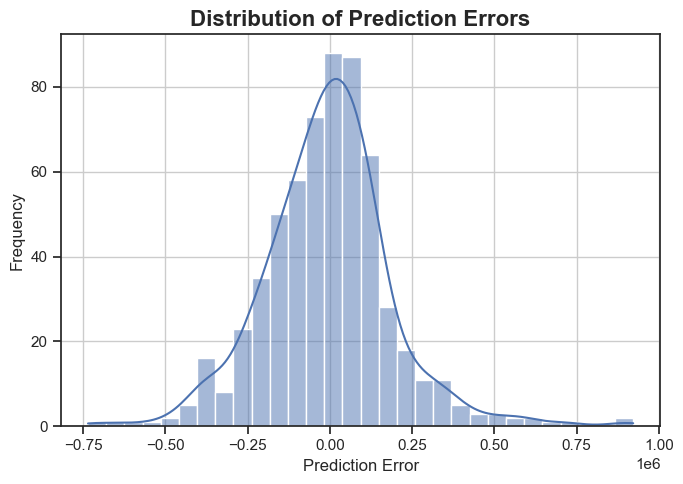

In [51]:
errors = y_test - y_pred
plt.figure(figsize=(7,5))
sns.histplot(
    errors,
    bins=30,
    kde=True
)
plt.title("Distribution of Prediction Errors", fontsize=16,fontweight='bold')
plt.xlabel("Prediction Error",fontsize=12)
plt.ylabel("Frequency",fontsize=12)
plt.tight_layout()
plt.grid(True)
plt.show()

## Decision Tree Regressor
Decision Tree Regressor predicts customer bank deposits by learning decision rules from the training data. Unlike Linear Regression, it can capture non-linear relationships and interactions between features, making it suitable for more complex patterns in banking data.

### Step 14: Train the Decision Tree Model

In [52]:
DT = DecisionTreeRegressor(random_state=42)
DT.fit(X_train, y_train)
print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


### Step 15: Make Predictions

In [53]:
dt_pred = DT.predict(X_test)
comparison_dt = pd.DataFrame({"Actual": y_test.values, "Predicted": dt_pred})
comparison_dt.head(10)

,Actual,Predicted
0,550849.92,776427.98
1,793170.72,505423.79
2,286537.87,154216.54
3,958605.57,524154.78
4,1020870.62,1418542.67
5,1217834.19,1685740.70
6,1392924.89,1278524.30
7,303439.38,166878.16
8,801883.53,816157.07
9,146402.02,145605.38


### Step 16: Evaluate the Model

In [66]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Performance")
print("-" * 35)
print(f"MAE      : {dt_mae:.2f}")
print(f"MSE      : {dt_mse:.2f}")
print(f"RMSE     : {dt_rmse:.2f}")
print(f"R² Score : {dt_r2:.4f}")

Decision Tree Performance
-----------------------------------
MAE      : 198864.92
MSE      : 95408194764.72
RMSE     : 308882.17
R² Score : 0.7732


### Step 17: Actual vs Predicted (Decision Tree)

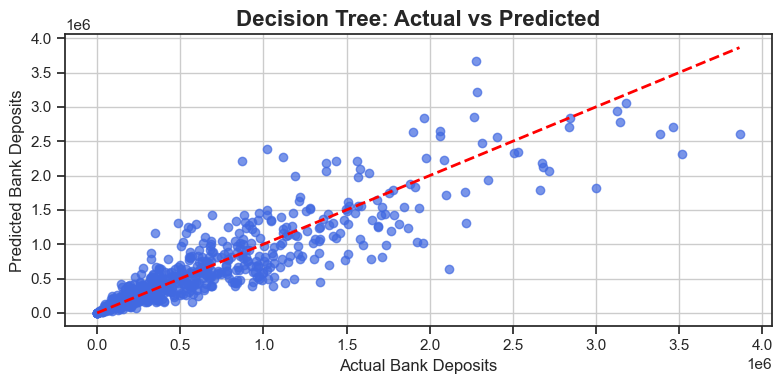

In [55]:
plt.figure(figsize=(8,4))
plt.scatter(y_test, dt_pred, alpha=0.7, c='royalblue')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    ls='--',
    linewidth=2
)
plt.title("Decision Tree: Actual vs Predicted",fontsize=16,fontweight='bold')
plt.xlabel("Actual Bank Deposits",fontsize=12)
plt.ylabel("Predicted Bank Deposits",fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

### Step 18: Feature Importance

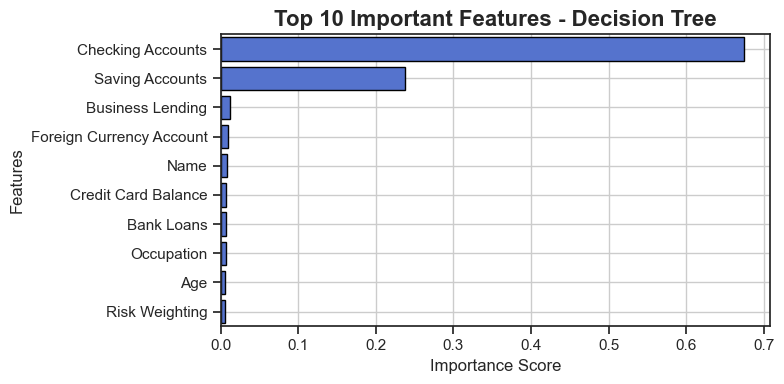

In [56]:
feature_importance = pd.DataFrame({"Feature": X.columns, "Importance": DT.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    color='royalblue',
    edgecolor='black'
)
plt.title("Top 10 Important Features - Decision Tree",fontsize=16, fontweight='bold')
plt.xlabel("Importance Score",fontsize=12)
plt.ylabel("Features",fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

## Random Forest Regressor

### Step 19: Train the Random Forest Model

In [57]:
RF = RandomForestRegressor(n_estimators=100, random_state=42)
RF.fit(X_train, y_train)
print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


### Step 20: Make Predictions

In [58]:
rf_pred = RF.predict(X_test)
comparison_rf = pd.DataFrame({"Actual": y_test.values, "Predicted": rf_pred})
comparison_rf.head(10)

,Actual,Predicted
0,550849.92,8.169050e+05
1,793170.72,8.911102e+05
2,286537.87,3.670904e+05
3,958605.57,5.331977e+05
4,1020870.62,1.379451e+06
5,1217834.19,1.358586e+06
6,1392924.89,1.253604e+06
7,303439.38,2.183449e+05
8,801883.53,8.610728e+05
9,146402.02,1.483844e+05


### Step 21: Evaluate the Model

In [67]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print("-" * 35)
print(f"MAE      : {rf_mae:.2f}")
print(f"MSE      : {rf_mse:.2f}")
print(f"RMSE     : {rf_rmse:.2f}")
print(f"R² Score : {rf_r2:.4f}")

Random Forest Performance
-----------------------------------
MAE      : 148649.31
MSE      : 49018917249.81
RMSE     : 221402.16
R² Score : 0.8835


### Step 22: Actual vs Predicted (Random Forest)

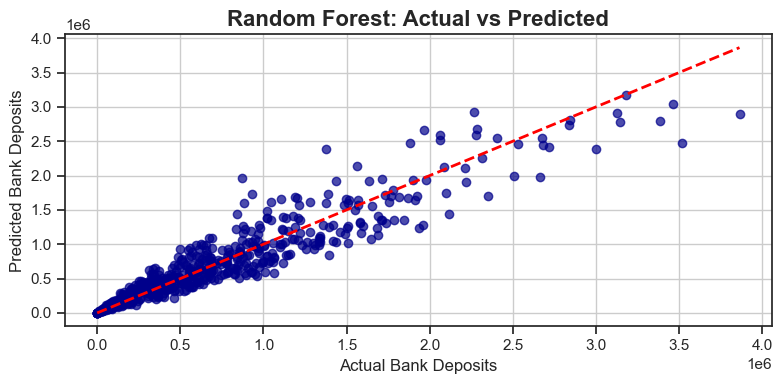

In [60]:
plt.figure(figsize=(8,4))
plt.scatter(y_test, rf_pred, alpha=0.7, color='darkblue')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    ls='--',
    linewidth=2
)
plt.title("Random Forest: Actual vs Predicted",fontsize=16, fontweight='bold')
plt.xlabel("Actual Bank Deposits",fontsize=12)
plt.ylabel("Predicted Bank Deposits",fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

### Step 23: Feature Importance

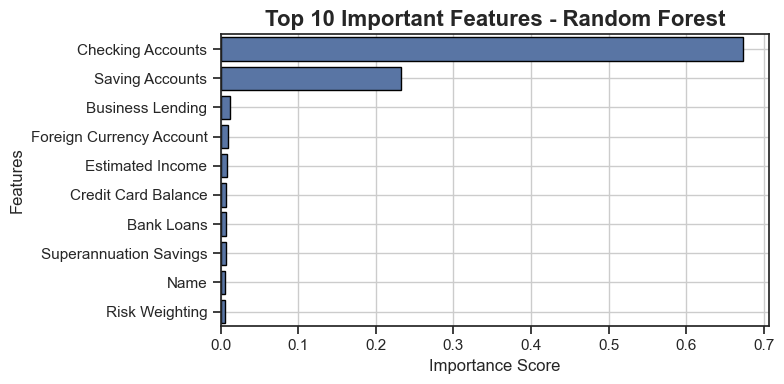

In [61]:
feature_importance_rf = pd.DataFrame({"Feature": X.columns, "Importance": RF.feature_importances_})
feature_importance_rf = feature_importance_rf.sort_values(by="Importance", ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(
    data=feature_importance_rf.head(10),
    x="Importance",
    y="Feature",
    edgecolor='black'
)
plt.title("Top 10 Important Features - Random Forest",fontsize=16, fontweight='bold')
plt.xlabel("Importance Score",fontsize=12)
plt.ylabel("Features",fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

### Step 24: Compare All Models

In [62]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [mae, dt_mae, rf_mae],
    "MSE": [mse, dt_mse, rf_mse],
    "RMSE": [rmse, dt_rmse, rf_rmse],
    "R² Score": [r2, dt_r2, rf_r2]
})
model_comparison

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,141245.144104,3.771497e+10,194203.420414,0.910349
1,Decision Tree,198864.919583,9.540819e+10,308882.169710,0.773208
2,Random Forest,148649.314934,4.901892e+10,221402.161800,0.883479


## 8. Final Visualization

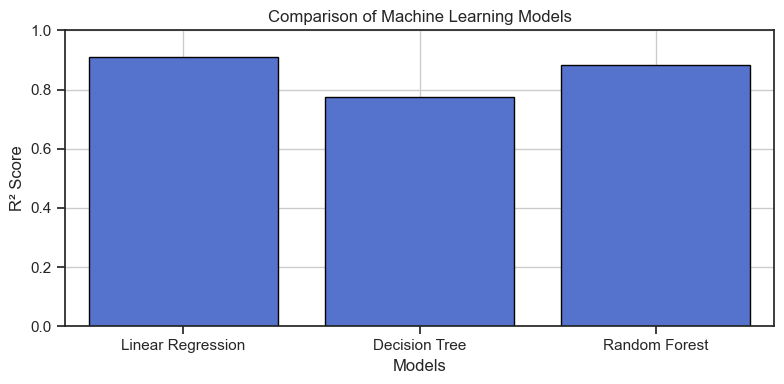

In [64]:
plt.figure(figsize=(8,4))
sns.barplot(
    data=model_comparison,
    x="Model",
    y="R² Score",
    edgecolor='black',
    color='royalblue'
)
plt.title("Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

## 9. Cleaned csv file

In [74]:
df.to_csv("Banking_Analytics_Cleaned.csv", index=False)

## 10.Conclusion

This project successfully analyzed customer demographics and financial behavior using Exploratory Data Analysis (EDA) and Machine Learning techniques. Multiple regression models were developed and compared to predict customer bank deposits, enabling the selection of the best-performing model. The insights generated from this analysis can support customer segmentation, personalized banking services, and data-driven business decision-making.